In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
DATA_PATH = Path("../data/raw/flights_2025_01.csv")

df = pd.read_csv(DATA_PATH, low_memory=False)

completed = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0) &
    (df["ARR_DEL15"].notna())
].copy()

completed.shape

(522269, 26)

In [3]:
completed["ROUTE"] = completed["ORIGIN"] + "_" + completed["DEST"]

completed["DEP_HOUR"] = completed["CRS_DEP_TIME"] // 100
completed["ARR_HOUR"] = completed["CRS_ARR_TIME"] // 100

completed["IS_WEEKEND"] = completed["DAY_OF_WEEK"].isin([6, 7]).astype(int)

completed["IS_MORNING_FLIGHT"] = completed["DEP_HOUR"].between(5, 11).astype(int)
completed["IS_AFTERNOON_FLIGHT"] = completed["DEP_HOUR"].between(12, 16).astype(int)
completed["IS_EVENING_FLIGHT"] = completed["DEP_HOUR"].between(17, 21).astype(int)
completed["IS_NIGHT_FLIGHT"] = (
    (completed["DEP_HOUR"] >= 22) | (completed["DEP_HOUR"] <= 4)
).astype(int)

completed[[
    "CRS_DEP_TIME",
    "DEP_HOUR",
    "CRS_ARR_TIME",
    "ARR_HOUR",
    "IS_WEEKEND",
    "IS_MORNING_FLIGHT",
    "IS_AFTERNOON_FLIGHT",
    "IS_EVENING_FLIGHT",
    "IS_NIGHT_FLIGHT",
    "ROUTE"
]].head()

,CRS_DEP_TIME,DEP_HOUR,CRS_ARR_TIME,ARR_HOUR,IS_WEEKEND,IS_MORNING_FLIGHT,IS_AFTERNOON_FLIGHT,IS_EVENING_FLIGHT,IS_NIGHT_FLIGHT,ROUTE
0,1030,10,1912,19,0,1,0,0,0,SFO_JFK
1,600,6,940,9,0,1,0,0,0,JFK_SFO
2,819,8,1206,12,0,1,0,0,0,SAT_CLT
3,2100,21,29,0,0,0,0,1,0,JFK_LAX
4,801,8,1140,11,0,1,0,0,0,BOS_LAX


In [4]:
target = "ARR_DEL15"

base_numeric_features = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "DISTANCE",
    "DISTANCE_GROUP",
    "DEP_HOUR",
    "ARR_HOUR",
    "IS_WEEKEND",
    "IS_MORNING_FLIGHT",
    "IS_AFTERNOON_FLIGHT",
    "IS_EVENING_FLIGHT",
    "IS_NIGHT_FLIGHT"
]

categorical_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK"
]

helper_columns = [
    "ROUTE"
]

features = base_numeric_features + categorical_features + helper_columns

X = completed[features].copy()
y = completed[target].astype(int)

X.shape, y.shape

((522269, 20), (522269,))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((417815, 20), (104454, 20))

In [12]:
def make_smoothed_rate_map(X_train, y_train, column, smoothing=100):
    temp = pd.DataFrame({
        column: X_train[column],
        "target": y_train
    })

    global_rate = y_train.mean()

    stats = (
        temp
        .groupby(column)["target"]
        .agg(["sum", "count"])
    )

    stats["smoothed_rate"] = (
        stats["sum"] + global_rate * smoothing
    ) / (
        stats["count"] + smoothing
    )

    return stats["smoothed_rate"], global_rate


def add_rate_feature(X_train, X_test, y_train, column, new_column_name, smoothing=100):
    rate_map, global_rate = make_smoothed_rate_map(
        X_train=X_train,
        y_train=y_train,
        column=column,
        smoothing=smoothing
    )

    X_train = X_train.copy()
    X_test = X_test.copy()

    X_train[new_column_name] = X_train[column].map(rate_map).fillna(global_rate)
    X_test[new_column_name] = X_test[column].map(rate_map).fillna(global_rate)

    return X_train, X_test

In [13]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

X_train_fe, X_test_fe = add_rate_feature(
    X_train_fe,
    X_test_fe,
    y_train,
    column="ROUTE",
    new_column_name="ROUTE_DELAY_RATE",
    smoothing=100
)

X_train_fe, X_test_fe = add_rate_feature(
    X_train_fe,
    X_test_fe,
    y_train,
    column="OP_UNIQUE_CARRIER",
    new_column_name="AIRLINE_DELAY_RATE",
    smoothing=100
)

X_train_fe, X_test_fe = add_rate_feature(
    X_train_fe,
    X_test_fe,
    y_train,
    column="ORIGIN",
    new_column_name="ORIGIN_DELAY_RATE",
    smoothing=100
)

X_train_fe, X_test_fe = add_rate_feature(
    X_train_fe,
    X_test_fe,
    y_train,
    column="DEST",
    new_column_name="DEST_DELAY_RATE",
    smoothing=100
)

X_train_fe[[
    "ROUTE",
    "ROUTE_DELAY_RATE",
    "OP_UNIQUE_CARRIER",
    "AIRLINE_DELAY_RATE",
    "ORIGIN",
    "ORIGIN_DELAY_RATE",
    "DEST",
    "DEST_DELAY_RATE"
]].head()

,ROUTE,ROUTE_DELAY_RATE,OP_UNIQUE_CARRIER,AIRLINE_DELAY_RATE,ORIGIN,ORIGIN_DELAY_RATE,DEST,DEST_DELAY_RATE
401739,MCO_PHL,0.190643,AA,0.193866,MCO,0.186205,PHL,0.198298
276517,SMF_DEN,0.176891,UA,0.177068,SMF,0.129398,DEN,0.202650
215114,DFW_ONT,0.198972,AA,0.193866,DFW,0.217424,ONT,0.147709
29903,ORD_IAH,0.242223,UA,0.177068,ORD,0.213052,IAH,0.207138
88416,BNA_EWR,0.149042,UA,0.177068,BNA,0.169892,EWR,0.179156


In [14]:
engineered_numeric_features = base_numeric_features + [
    "ROUTE_DELAY_RATE",
    "AIRLINE_DELAY_RATE",
    "ORIGIN_DELAY_RATE",
    "DEST_DELAY_RATE"
]

final_categorical_features = categorical_features

final_features = engineered_numeric_features + final_categorical_features

X_train_final = X_train_fe[final_features].copy()
X_test_final = X_test_fe[final_features].copy()

X_train_final.shape, X_test_final.shape

((417815, 23), (104454, 23))

In [15]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_dense = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, engineered_numeric_features),
        ("cat", categorical_transformer_dense, final_categorical_features)
    ]
)

In [16]:
hgb_fe_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_dense),
        ("model", HistGradientBoostingClassifier(
            max_iter=100,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

hgb_fe_model.fit(X_train_final, y_train)

hgb_fe_probs = hgb_fe_model.predict_proba(X_test_final)[:, 1]

In [17]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

hgb_fe_threshold_results = []

for threshold in thresholds:
    preds = (hgb_fe_probs >= threshold).astype(int)

    hgb_fe_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0)
    })

hgb_fe_threshold_results_df = pd.DataFrame(hgb_fe_threshold_results)

hgb_fe_threshold_results_df.sort_values("f1", ascending=False)

,threshold,accuracy,precision,recall,f1
3,0.25,0.763140,0.399370,0.517171,0.450700
2,0.20,0.707106,0.347072,0.634159,0.448618
4,0.30,0.796446,0.454434,0.415673,0.434190
1,0.15,0.605807,0.290179,0.759248,0.419882
5,0.35,0.815373,0.513433,0.332060,0.403292
0,0.10,0.436881,0.236564,0.896668,0.374362
6,0.40,0.823769,0.570016,0.252624,0.350092
7,0.45,0.826670,0.630693,0.186997,0.288465
8,0.50,0.825828,0.692971,0.131102,0.220489


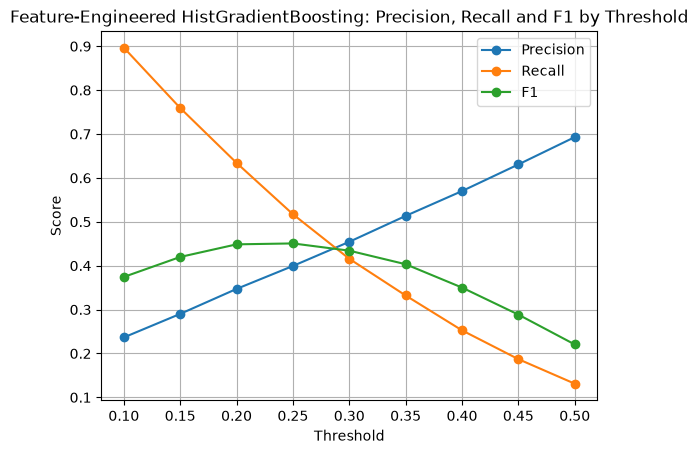

In [18]:
plt.plot(hgb_fe_threshold_results_df["threshold"], hgb_fe_threshold_results_df["precision"], marker="o", label="Precision")
plt.plot(hgb_fe_threshold_results_df["threshold"], hgb_fe_threshold_results_df["recall"], marker="o", label="Recall")
plt.plot(hgb_fe_threshold_results_df["threshold"], hgb_fe_threshold_results_df["f1"], marker="o", label="F1")

plt.title("Feature-Engineered HistGradientBoosting: Precision, Recall and F1 by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
previous_best = {
    "model": "Previous HGB",
    "threshold": 0.25,
    "accuracy": 0.774054,
    "precision": 0.416628,
    "recall": 0.506063,
    "f1": 0.457011
}

best_fe_row = hgb_fe_threshold_results_df.sort_values("f1", ascending=False).iloc[0].to_dict()
best_fe_row["model"] = "Feature-Engineered HGB"

comparison = pd.DataFrame([previous_best, best_fe_row])

comparison = comparison[
    ["model", "threshold", "accuracy", "precision", "recall", "f1"]
]

comparison

,model,threshold,accuracy,precision,recall,f1
0,Previous HGB,0.25,0.774054,0.416628,0.506063,0.457011
1,Feature-Engineered HGB,0.25,0.763140,0.399370,0.517171,0.450700


In [21]:
best_threshold = hgb_fe_threshold_results_df.sort_values("f1", ascending=False).iloc[0]["threshold"]

best_preds = (hgb_fe_probs >= best_threshold).astype(int)

print("Best Feature-Engineered Model")
print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, best_preds))
print("Precision:", precision_score(y_test, best_preds, zero_division=0))
print("Recall:", recall_score(y_test, best_preds, zero_division=0))
print("F1:", f1_score(y_test, best_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, hgb_fe_probs))

print()
print(classification_report(y_test, best_preds, zero_division=0))

Best Feature-Engineered Model
Threshold: 0.25
Accuracy: 0.7631397552989833
Precision: 0.3993704505213457
Recall: 0.5171710995618057
F1: 0.4507004729024666
ROC-AUC: 0.7409306309065967

              precision    recall  f1-score   support

           0       0.88      0.82      0.85     84828
           1       0.40      0.52      0.45     19626

    accuracy                           0.76    104454
   macro avg       0.64      0.67      0.65    104454
weighted avg       0.79      0.76      0.77    104454



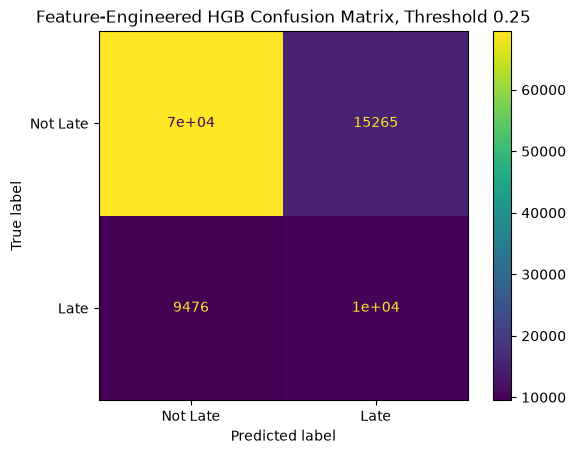

In [22]:
cm = confusion_matrix(y_test, best_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late", "Late"]
)

disp.plot()
plt.title(F"Feature-Engineered HGB Confusion Matrix, Threshold {best_threshold}")
plt.show()

In [23]:
Path("../visuals").mkdir(exist_ok=True)

hgb_fe_threshold_results_df.to_csv(
    "../visuals/hgb_feature_engineering_threshold_results.csv",
    index=False
)

comparison.to_csv(
    "../visuals/feature_engineering_comparison.csv",
    index=False
)
comparison

,model,threshold,accuracy,precision,recall,f1
0,NaN,0.25,0.774054,0.416628,0.506063,0.457011
1,Feature-Engineered HGB,0.25,0.763140,0.399370,0.517171,0.450700


The feature-engineered HistGradientBoosting model did not improve over the previous best model. Although recall increased slightly, precision decreased enough that the F1-score dropped from 0.4570 to 0.4507.

This shows that additional features do not always improve model performance. In this case, the delay-rate features may have been noisy or redundant with the existing airline, airport, and time-block features. The previous HistGradientBoosting model remains the best model so far.

In [29]:
# Rebuild the ORIGINAL HGB model without feature-engineered delay-rate columns

original_numeric_features = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "DISTANCE",
    "DISTANCE_GROUP"
]

original_categorical_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK"
]

original_features = original_numeric_features + original_categorical_features

X_original = completed[original_features].copy()
y_original = completed["ARR_DEL15"].astype(int)

X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original,
    y_original,
    test_size=0.20,
    random_state=42,
    stratify=y_original
)

original_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

original_categorical_transformer_dense = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

original_preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", original_numeric_transformer, original_numeric_features),
        ("cat", original_categorical_transformer_dense, original_categorical_features)
    ]
)

hgb_original_model = Pipeline(
    steps=[
        ("preprocessor", original_preprocessor_dense),
        ("model", HistGradientBoostingClassifier(
            max_iter=100,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

hgb_original_model.fit(X_train_original, y_train_original)

hgb_original_probs = hgb_original_model.predict_proba(X_test_original)[:, 1]

In [30]:
fine_thresholds = np.arange(0.20, 0.301, 0.01)

fine_hgb_results = []

for threshold in fine_thresholds:
    preds = (hgb_original_probs >= threshold).astype(int)

    fine_hgb_results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_test_original, preds),
        "precision": precision_score(y_test_original, preds, zero_division=0),
        "recall": recall_score(y_test_original, preds, zero_division=0),
        "f1": f1_score(y_test_original, preds, zero_division=0)
    })

fine_hgb_results_df = pd.DataFrame(fine_hgb_results)

fine_hgb_results_df.sort_values("f1", ascending=False)

,threshold,accuracy,precision,recall,f1
3,0.23,0.754696,0.391942,0.554163,0.459145
4,0.24,0.764672,0.403768,0.529655,0.458222
2,0.22,0.742729,0.379011,0.578365,0.457932
5,0.25,0.774054,0.416628,0.506063,0.457011
6,0.26,0.782220,0.429424,0.483950,0.455059
1,0.21,0.727449,0.363857,0.602109,0.453602
0,0.20,0.711998,0.351154,0.628503,0.450569
7,0.27,0.789122,0.441276,0.459645,0.450273
8,0.28,0.794943,0.452609,0.436258,0.444283
9,0.29,0.801013,0.466838,0.415673,0.439773


In [31]:
best_threshold = 0.23

best_preds = (hgb_original_probs >= best_threshold).astype(int)

print("Best Model So Far: Original HistGradientBoosting")
print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test_original, best_preds))
print("Precision:", precision_score(y_test_original, best_preds, zero_division=0))
print("Recall:", recall_score(y_test_original, best_preds, zero_division=0))
print("F1:", f1_score(y_test_original, best_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test_original, hgb_original_probs))

print()
print(classification_report(y_test_original, best_preds, zero_division=0))

Best Model So Far: Original HistGradientBoosting
Threshold: 0.23
Accuracy: 0.7546958469757022
Precision: 0.3919420519658366
Recall: 0.5541628452053399
F1: 0.4591451187335092
ROC-AUC: 0.7437032269075124

              precision    recall  f1-score   support

           0       0.89      0.80      0.84     84828
           1       0.39      0.55      0.46     19626

    accuracy                           0.75    104454
   macro avg       0.64      0.68      0.65    104454
weighted avg       0.79      0.75      0.77    104454



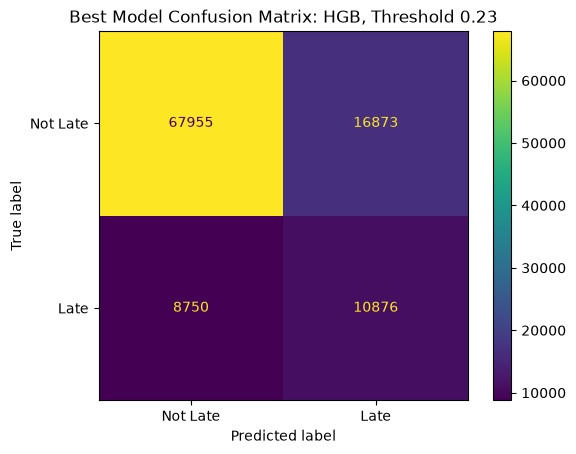

In [32]:
cm = confusion_matrix(y_test_original, best_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late", "Late"]
)

disp.plot()
plt.title("Best Model Confusion Matrix: HGB, Threshold 0.23")
plt.show()

In [33]:
Path("../visuals").mkdir(exist_ok=True)

fine_hgb_results_df.to_csv(
    "../visuals/fine_hgb_threshold_results.csv",
    index=False
)